# Calculating neuron tuning to stim1 identity

Plan is to look at neuron firing rate during stim1 encoding period
- calculate whether there is a significant difference between fr when stim1 is +1 versus -1


SAVE TUNING FOR GOOD MODELS, BAD MODELS, DELAY 50, DELAY 150

In [1]:
import numpy as np 
import sys
from matplotlib import pyplot as plt
import matplotlib.patches as patches
import scipy
import os
import importlib
import pandas as pd
from scipy.io import savemat

sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/analysis/utils')
import load_data as ld 
import single_neuron_utils as sn 
import bhv_utils as bhv
from bootstrap_method import *



2025-06-05 12:00:03.407799: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-06-05 12:00:03.416496: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-06-05 12:00:03.425552: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-06-05 12:00:03.428252: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-06-05 12:00:03.435985: I tensorflow/core/platform/cpu_feature_guar

In [2]:
delay = [50, 150]
condn_phrase = 'delay'

In [3]:
# find folder names within model directory
all_models_dir = '/home/nuttidalab/Documents/renee/all_DMS_models/'

model_dirs = ld.get_immediate_subdirs(all_models_dir)
print(model_dirs)


['Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_231815', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_11_06_084645', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_212818', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_07_011809', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_163926', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_160648', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_225459', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_165543', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_221440', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_225727', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_175711', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_174328', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_204320', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_212723', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_234449', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_07_032739', 'Task_x

## Calculate tuning, and save for all neurons

In [5]:
import concurrent.futures

In [6]:
def process_model_condn(args):
    model_name, condn_num, condn_phrase, all_models_dir = args
    tuning = sn.calc_stim1_tuning_spikes(model_name, condn_phrase, condn_num)
    untuned_idx = np.where(np.isnan(tuning))[0]

    save_path = os.path.join(all_models_dir, model_name, f'tuning_{condn_phrase}_{condn_num}.mat')
    savemat(save_path, {'tuning': tuning, 'untuned_idx': untuned_idx})

    return f'Saved tuning for {model_name} at {condn_phrase} {condn_num} with {len(untuned_idx)} untuned neurons.'

# Prepare tasks
tasks = []
for model_name in model_dirs:
    for condn_num in delay:
        tasks.append((model_name, condn_num, condn_phrase, all_models_dir))

# Run in parallel
with concurrent.futures.ProcessPoolExecutor() as executor:
    for result in executor.map(process_model_condn, tasks):
        print(result)


Saved tuning for Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_231815 at delay 50 with 21 untuned neurons.
Saved tuning for Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_231815 at delay 150 with 12 untuned neurons.
Saved tuning for Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_11_06_084645 at delay 50 with 22 untuned neurons.
Saved tuning for Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_11_06_084645 at delay 150 with 26 untuned neurons.
Saved tuning for Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_212818 at delay 50 with 15 untuned neurons.
Saved tuning for Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_212818 at delay 150 with 14 untuned neurons.
Saved tuning for Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_07_011809 at delay 50 with 21 untuned neurons.
Saved tuning for Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_07_011809 at delay 150 with 26 untuned neurons.
Saved tuning for Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_163926 at delay 50 with

## Plot number untuned neurons per model

In [6]:
good_models, good_perfs = ld.get_models_by_perf(low_cutoff=0.95, high_cutoff=np.inf,
                                              condn_phrase='delay', condn_num=150)
bad_models, bad_perfs = ld.get_models_by_perf(low_cutoff=0.6, high_cutoff=0.8,
                                              condn_phrase='delay', condn_num=150)

Found 32 models with performance between 0.95 and inf
Found 28 models with performance between 0.6 and 0.8


In [7]:
good_untuned = np.zeros(len(good_models))
bad_untuned = np.zeros(len(bad_models))
for i, model_name in enumerate(good_models):
    tuning = sn.calc_stim1_tuning_spikes(model_name, condn_phrase, 150)
    good_untuned[i] = np.sum(np.isnan(tuning))
for i, model_name in enumerate(bad_models):
    tuning = sn.calc_stim1_tuning_spikes(model_name, condn_phrase, 150)
    bad_untuned[i] = np.sum(np.isnan(tuning))
print('Good models untuned:', good_untuned)
print('Bad models untuned:', bad_untuned)

Good models untuned: [14. 13. 15. 10. 23. 14. 25. 20. 15. 15. 15. 21. 13. 14. 20. 18. 12. 18.
 21. 20. 13. 26. 21. 12. 13. 14. 11. 15. 19. 26. 18. 10.]
Bad models untuned: [26. 16. 20. 18. 15. 33. 16. 15. 17. 20. 52. 10. 17. 16. 23. 15. 19. 12.
 20. 24. 18. 51. 12. 50. 21. 11.  7.  9.]


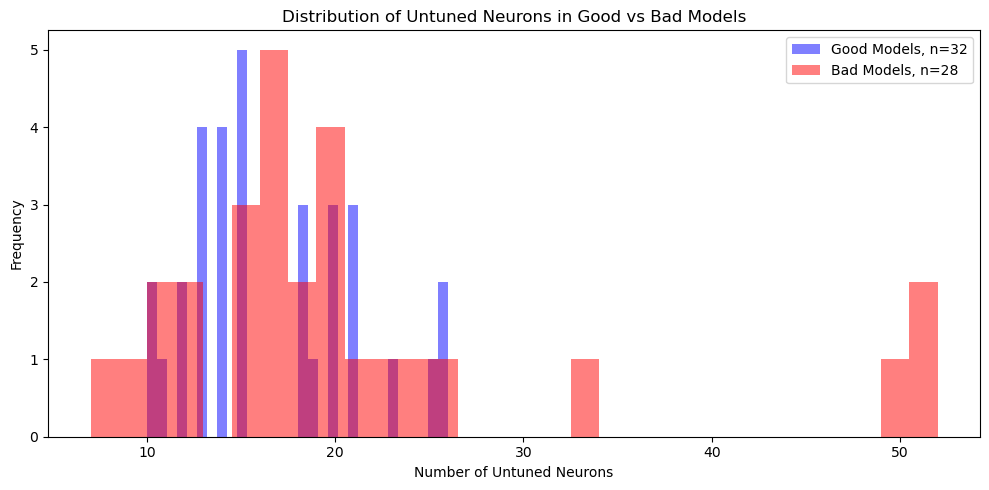

In [10]:
# plot as histograms

plt.figure(figsize=(10, 5))
plt.hist(good_untuned, bins=30, alpha=0.5, label=f'Good Models, n={len(good_untuned)}', color='blue')
plt.hist(bad_untuned, bins=30, alpha=0.5, label=f'Bad Models, n={len(bad_untuned)}', color='red')
plt.xlabel('Number of Untuned Neurons')
plt.ylabel('Frequency')
plt.title('Distribution of Untuned Neurons in Good vs Bad Models')
plt.legend()
plt.tight_layout()
plt.show()

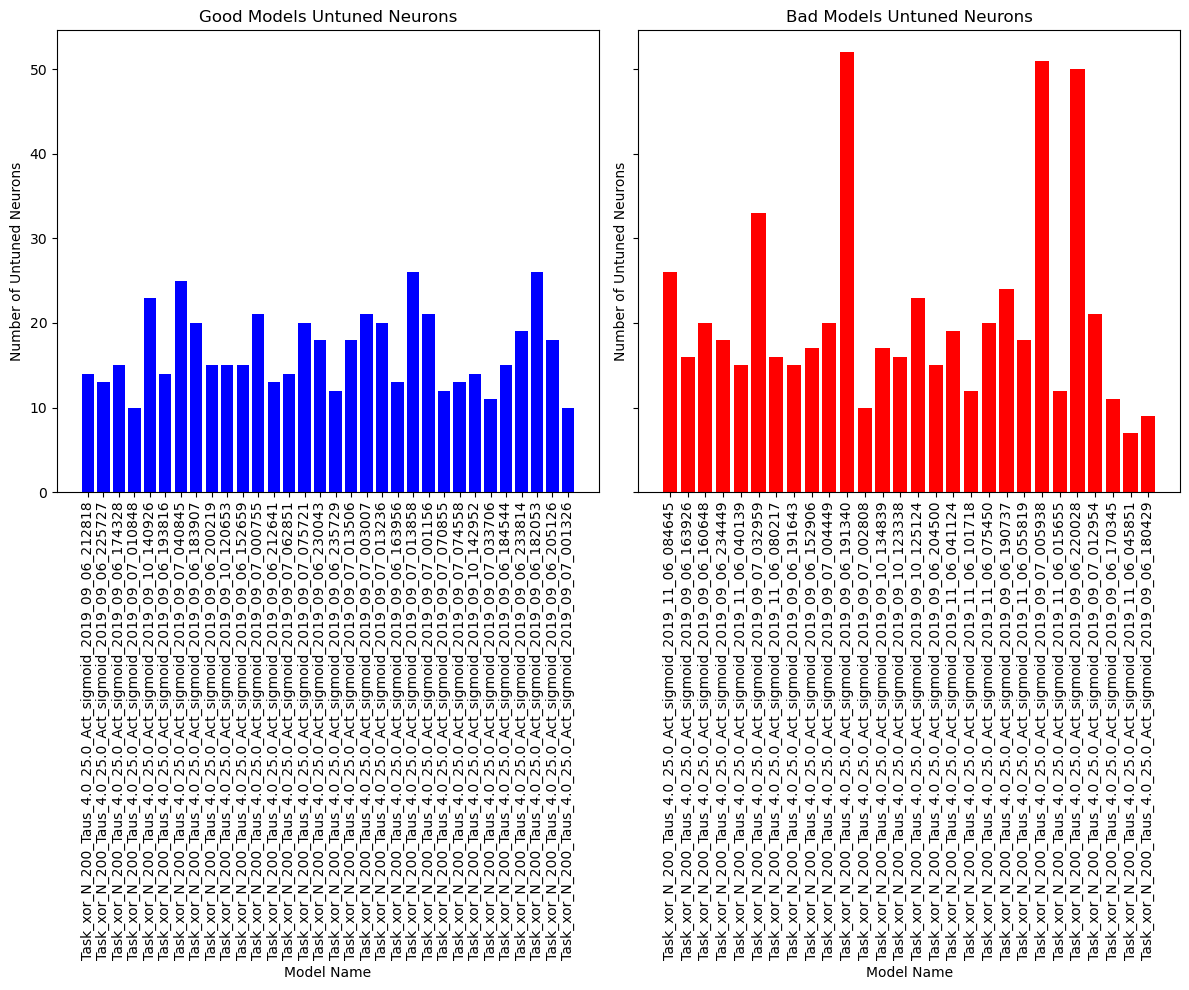

In [17]:
# plot bar graphs for each model
fig, axs = plt.subplots(1, 2, figsize=(12, 10), sharey=True)
axs[0].bar(good_models, good_untuned, color='blue')
axs[0].set_title('Good Models Untuned Neurons')
axs[0].set_xlabel('Model Name')
axs[0].set_ylabel('Number of Untuned Neurons')
axs[0].set_xticks(good_models)
axs[0].set_xticklabels(good_models, rotation=90)
axs[0].tick_params(axis='x', rotation=90)
axs[1].bar(bad_models, bad_untuned, color='red')
axs[1].set_title('Bad Models Untuned Neurons')
axs[1].set_xlabel('Model Name')
axs[1].set_xticks(bad_models)
axs[1].set_xticklabels(bad_models, rotation=90)
axs[1].set_ylabel('Number of Untuned Neurons')
axs[1].tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.show()

Mann-Whitney U test: U-statistic=374.0, p-value=0.27481526193397265


/tmp/ipykernel_1604894/3314997371.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([good_untuned, bad_untuned], labels=['Good Models', 'Bad Models'])


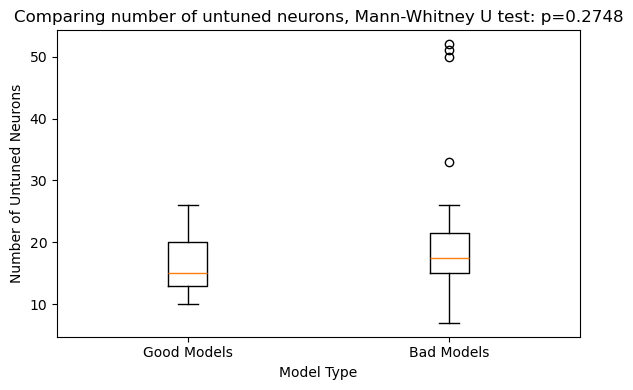

In [15]:
# plot as boxplots with mann-whitney U test
plt.figure(figsize=(6,4))
plt.boxplot([good_untuned, bad_untuned], labels=['Good Models', 'Bad Models'])

# stats
from scipy.stats import mannwhitneyu
stat, p_value = mannwhitneyu(good_untuned, bad_untuned)
print(f'Mann-Whitney U test: U-statistic={stat}, p-value={p_value}')
plt.title(f'Comparing number of untuned neurons, Mann-Whitney U test: p={p_value:.4f}')
plt.xlabel('Model Type')
plt.xticks([1, 2], ['Good Models', 'Bad Models'])
plt.ylabel('Number of Untuned Neurons')
plt.tight_layout()
plt.show()

### now removing neurons with low fr (<2Hz)

In [ ]:
good_models, good_perfs = ld.get_models_by_perf(low_cutoff=0.95, high_cutoff=np.inf,
                                              condn_phrase='delay', condn_num=150)
bad_models, bad_perfs = ld.get_models_by_perf(low_cutoff=0.6, high_cutoff=0.8,
                                              condn_phrase='delay', condn_num=150)

Found 32 models with performance between 0.95 and inf
Found 28 models with performance between 0.6 and 0.8


In [18]:
good_untuned = np.zeros(len(good_models))
bad_untuned = np.zeros(len(bad_models))
for i, model_name in enumerate(good_models):
    tuning = sn.calc_stim1_tuning_spikes(model_name, condn_phrase, 150)
    low_fr = ld.load_lowfr_idxs(model_name, condn_phrase, 150, threshold=2)
    good_untuned[i] = np.sum(np.isnan(tuning[~low_fr]))
for i, model_name in enumerate(bad_models):
    tuning = sn.calc_stim1_tuning_spikes(model_name, condn_phrase, 150)
    low_fr = ld.load_lowfr_idxs(model_name, condn_phrase, 150, threshold=2)
    bad_untuned[i] = np.sum(np.isnan(tuning[~low_fr]))
print('Good models untuned:', good_untuned)
print('Bad models untuned:', bad_untuned)

Good models untuned: [0. 1. 0. 0. 1. 1. 2. 3. 0. 1. 1. 1. 2. 1. 1. 1. 1. 2. 2. 1. 0. 2. 1. 1.
 0. 1. 0. 1. 0. 2. 2. 0.]
Bad models untuned: [ 3.  0.  0.  0.  1.  8.  0.  2.  0.  1. 20.  0.  1.  0.  1.  1.  1.  0.
  0.  4.  0.  9.  1.  7.  2.  3.  0.  0.]


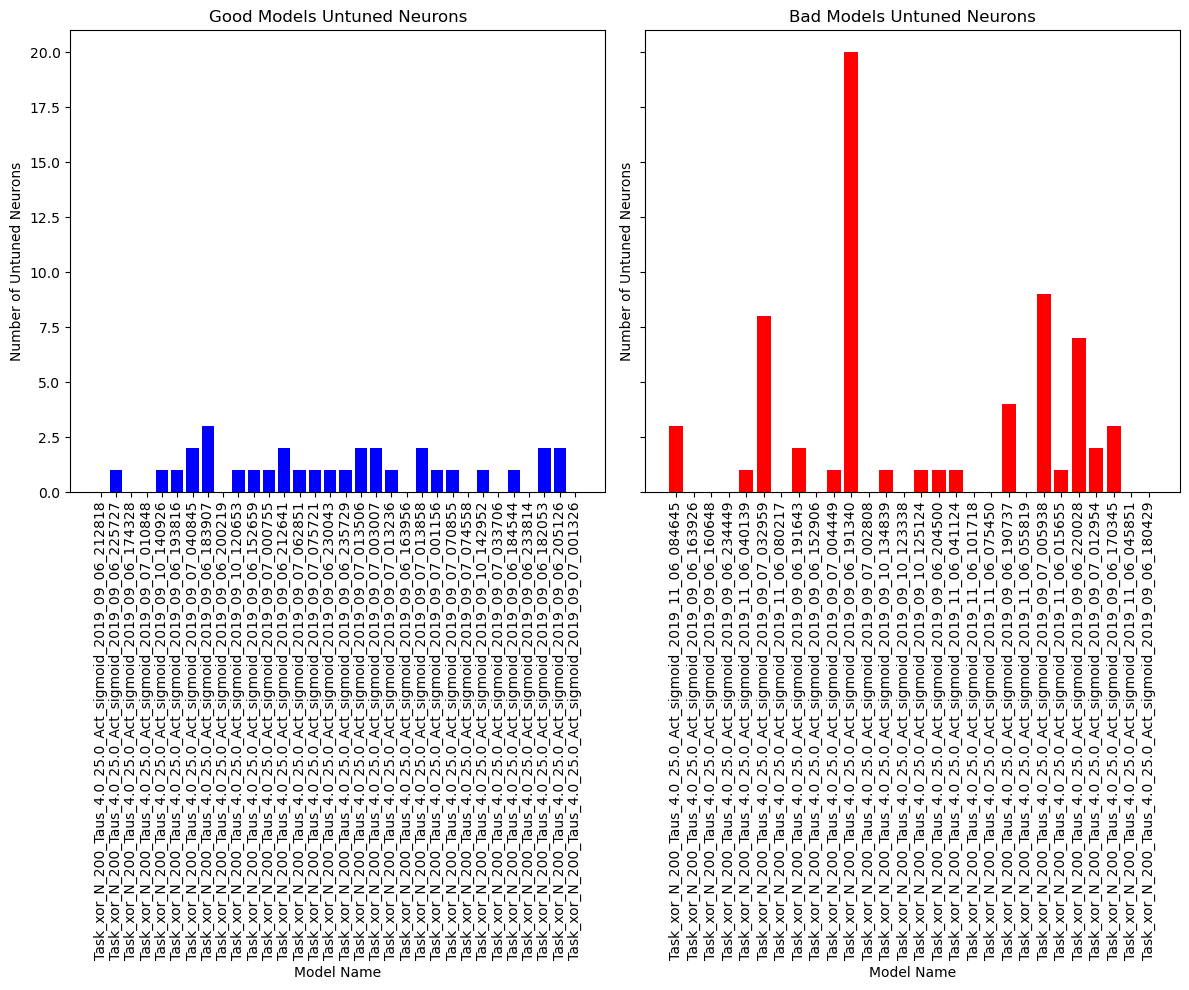

In [19]:
# plot bar graphs for each model
fig, axs = plt.subplots(1, 2, figsize=(12, 10), sharey=True)
axs[0].bar(good_models, good_untuned, color='blue')
axs[0].set_title('Good Models Untuned Neurons')
axs[0].set_xlabel('Model Name')
axs[0].set_ylabel('Number of Untuned Neurons')
axs[0].set_xticks(good_models)
axs[0].set_xticklabels(good_models, rotation=90)
axs[0].tick_params(axis='x', rotation=90)
axs[1].bar(bad_models, bad_untuned, color='red')
axs[1].set_title('Bad Models Untuned Neurons')
axs[1].set_xlabel('Model Name')
axs[1].set_xticks(bad_models)
axs[1].set_xticklabels(bad_models, rotation=90)
axs[1].set_ylabel('Number of Untuned Neurons')
axs[1].tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.show()

Mann-Whitney U test: U-statistic=448.5, p-value=1.0


/tmp/ipykernel_1604894/3314997371.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([good_untuned, bad_untuned], labels=['Good Models', 'Bad Models'])


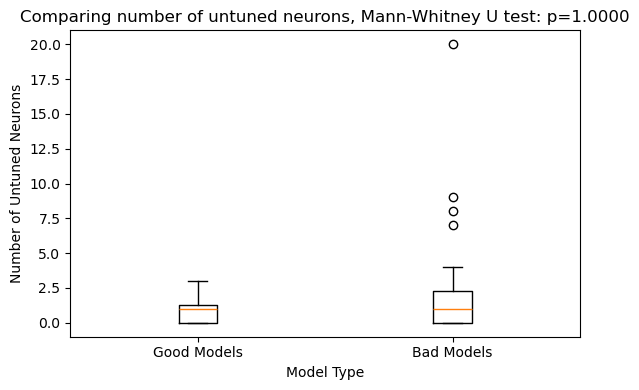

In [20]:
# plot as boxplots with mann-whitney U test
plt.figure(figsize=(6,4))
plt.boxplot([good_untuned, bad_untuned], labels=['Good Models', 'Bad Models'])

# stats
from scipy.stats import mannwhitneyu
stat, p_value = mannwhitneyu(good_untuned, bad_untuned)
print(f'Mann-Whitney U test: U-statistic={stat}, p-value={p_value}')
plt.title(f'Comparing number of untuned neurons, Mann-Whitney U test: p={p_value:.4f}')
plt.xlabel('Model Type')
plt.xticks([1, 2], ['Good Models', 'Bad Models'])
plt.ylabel('Number of Untuned Neurons')
plt.tight_layout()
plt.show()